In [42]:
import pandas as pd
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import os
from datetime import datetime, time, timedelta
from sklearn.metrics import mean_squared_error as mse
from scipy.integrate import simpson
from numpy import unravel_index
import pvlib
import sys
%run PV_Power_Function.ipynb import PV_Power import optimal_tilt_azimuth import PV_Power_Test

In [43]:
#Weather_and_PV_Data = pd.read_excel("C:\\Users\\Lenovo\\OneDrive - Ashesi University\\Desktop\\Master Thesis\\Energy_prod_data\\new_data02.xlsx")
Weather_and_PV_Data = pd.read_excel('C:/Users/Lenovo/OneDrive - Ashesi University/Desktop/Master Thesis/Energy_prod_data/Full_One_Year_Irradiance_Data.xlsx', engine='openpyxl')
Weather_and_PV_Data.head(5)

,Datetime,Hour,GHI,DNI,DHI,KT,Temp,WS10M
0,2023-05-01 01:00:00,01:00:00,0.0,0.0,0.0,-999.0,26.8,3.49
1,2023-05-01 02:00:00,02:00:00,0.0,0.0,0.0,-999.0,26.6,3.52
2,2023-05-01 03:00:00,03:00:00,0.0,0.0,0.0,-999.0,26.3,3.38
3,2023-05-01 04:00:00,04:00:00,0.0,0.0,0.0,-999.0,26.2,3.26
4,2023-05-01 05:00:00,05:00:00,0.0,0.0,0.0,-999.0,26.5,3.44


## Modelling Production of the Engineering Section

In [44]:
Engineering_Building_panels_azimuth = np.array([253.57, 75.22, 294.17, 111.85, 343, 159.21])
Rated_Array_Power_per_azimuth = np.array([25*270, 32*270, 60*270, 81*270, 12*270, 28*270])

N_day = np.array(Weather_and_PV_Data['Datetime'].dt.dayofyear)
#Hour_oftheDay = np.array(Weather_and_PV_Data['Hours'])
Hour_oftheDay = np.array(Weather_and_PV_Data['Datetime'].dt.hour)
#GHI_Irradiance = np.array(Weather_and_PV_Data['Solarradiation'])
GHI_Irradiance = np.array(Weather_and_PV_Data['GHI'])
Ambient_Temp = np.array(Weather_and_PV_Data['Temp'])
#Wind_Speed = np.array(Weather_and_PV_Data['Windspeed'])
Wind_Speed = np.array(Weather_and_PV_Data['WS10M'])
Location_lat = 5.7603
Engineering_Building_tilt_angle = 15

Total_Power_Production_KW = np.empty((len(GHI_Irradiance)))
Power_Production_in_azimuth_directions = np.empty((len(GHI_Irradiance), len(Engineering_Building_panels_azimuth)))
Irradiance_in_azimuth_directions = np.empty((len(GHI_Irradiance), len(Engineering_Building_panels_azimuth)))
Temperature_in_azimuth_directions = np.empty((len(GHI_Irradiance), len(Engineering_Building_panels_azimuth)))


#Installed_PV_Actual_Production_AC = np.array(Weather_and_PV_Data['Internal_Production'])
Datetimes = np.array(Weather_and_PV_Data['Datetime'])

In [45]:
#sol = optimal_tilt_azimuth(N_day, Hour_oftheDay, Location_lat, GHI_Irradiance, stc_power, Ambient_Temp, Wind_Speed)

#sol

power = PV_Power(N_day, Hour_oftheDay, Location_lat, Engineering_Building_tilt_angle, Engineering_Building_panels_azimuth, GHI_Irradiance, Rated_Array_Power_per_azimuth, 
                 Ambient_Temp, Wind_Speed)

# sol = PV_Power(N_day, Hour_oftheDay, Location_lat, Engineering_Building_tilt_angle, Engineering_Building_panels_azimuth, GHI_Irradiance, Rated_Array_Power_per_azimuth, Ambient_Temp, Wind_Speed)

In [16]:
#max(sol, key = sol.get)

In [46]:
sol1 = optimal_tilt_azimuth(N_day, Hour_oftheDay, Location_lat, GHI_Irradiance, Rated_Array_Power_per_azimuth, Ambient_Temp, Wind_Speed)
sol1

{'0-90': np.float64(303602.74480848806),
 '1-90': np.float64(301967.79160237854),
 '2-90': np.float64(300395.5518917008),
 '3-90': np.float64(298890.23433118),
 '4-90': np.float64(297455.8441001255),
 '5-90': np.float64(296096.17736137914),
 '6-90': np.float64(294814.816012265),
 '7-90': np.float64(293615.12273410795),
 '8-90': np.float64(292500.236346566),
 '9-90': np.float64(291473.0674725676),
 '10-90': np.float64(290536.29451933183),
 '11-90': np.float64(289692.3599804663),
 '12-90': np.float64(288943.4670638127),
 '13-90': np.float64(288291.5766492672),
 '14-90': np.float64(287738.4045803679),
 '15-90': np.float64(287285.4192930779),
 '16-90': np.float64(286933.8397847105),
 '17-90': np.float64(286684.6339255646),
 '18-90': np.float64(286538.5171153805),
 '19-90': np.float64(286495.95128629985),
 '20-90': np.float64(286557.1442535935),
 '21-90': np.float64(286722.04941496305),
 '22-90': np.float64(286990.36579880357),
 '23-90': np.float64(287361.5384613757),
 '24-90': np.float64(2

In [47]:
max(sol1, key = sol1.get)

'74-90'

In [262]:
(np.sum((Weather_and_PV_Data['Internal_Production'] - sol)**2))/len(sol)

np.float64(38.02102902088152)

### Visualization of DC/AC Power Output from the Model and Comparing with the Actual Production @ the Engineering Section

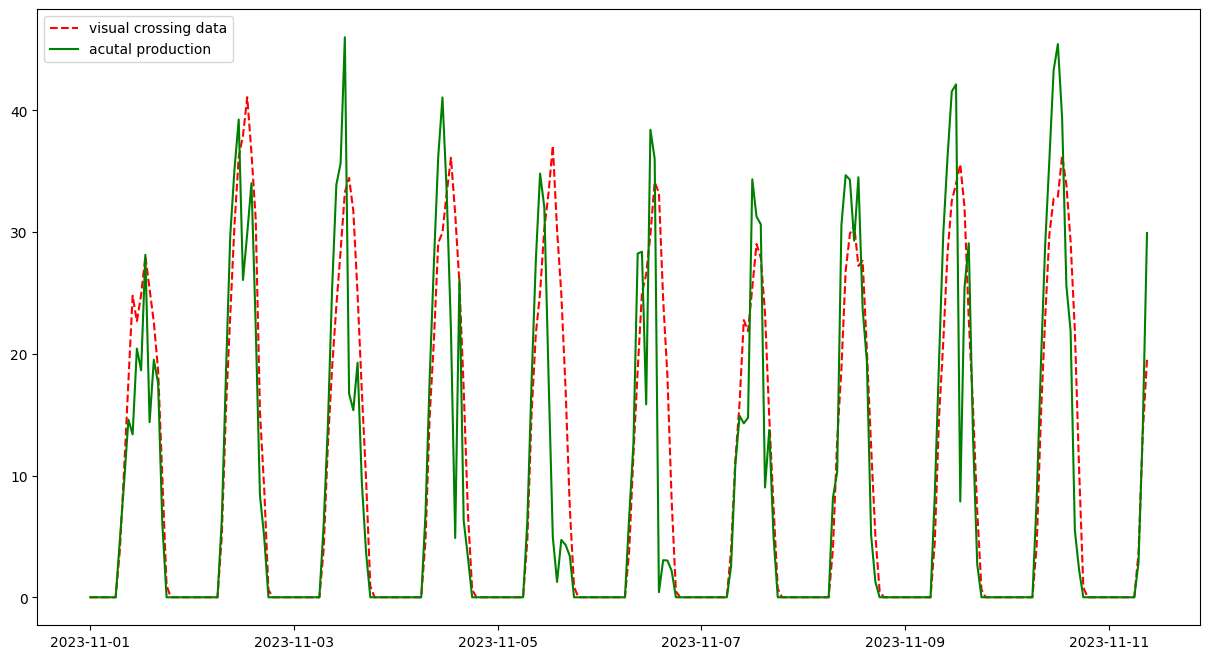

In [264]:
plt.figure(figsize = (15, 8))
plt.plot(Weather_and_PV_Data['Datetime'][:250], pd.DataFrame(sol[:250]), 'r--', label = 'visual crossing data')
plt.plot(Weather_and_PV_Data['Datetime'][:250], Weather_and_PV_Data['Internal_Production'][:250], 'g', label= 'acutal production')
plt.legend()
plt.show()

In [202]:
Model_total_Energy_AC = np.sum(sol)
print(f'Total Model AC Energy Output: {round(Model_total_Energy_AC, 2)} KWh')

Actual_total_Energy = np.sum(np.array(Weather_and_PV_Data['Internal_Production']))
print(f'Total Actual AC Energy Output: {round(Actual_total_Energy, 2)} KWh')
print('')
print(f'Percent difference between Total Model AC and Actual AC Energy Output: {round(((Model_total_Energy_AC - Actual_total_Energy)/Actual_total_Energy) * 100, 2)}%')
print(f'Mean Squared Error: {mse(Weather_and_PV_Data['Internal_Production'], sol)}')

Total Model AC Energy Output: 37095.4 KWh
Total Actual AC Energy Output: 31515.54 KWh

Percent difference between Total Model AC and Actual AC Energy Output: 17.71%
Mean Squared Error: 38.02102902088152


## Preprocessing for Visualization

In [193]:
Month_hours = [720, 744, 144, 576, 720, 744]
monthly_actual_energy_output = []
monthly_modelled_energy_output_AC = []
#monthly_modelled_energy_output_DC = []

start = 0
for hours in Month_hours:
    monthly_actual_power_sum = np.sum(np.array(Weather_and_PV_Data['Internal_Production'][start:start + hours]))
    monthly_modelled_AC_power_sum = np.sum(np.array(sol[start:start + hours]))
    #monthly_modelled_DC_power_sum = np.sum(np.array(Output_Dataframe['Model PV_DC_Power'][start:start + hours]))
    
    monthly_actual_energy_output.append(monthly_actual_power_sum)
    monthly_modelled_energy_output_AC.append(monthly_modelled_AC_power_sum)
    #monthly_modelled_energy_output_DC.append(monthly_modelled_DC_power_sum)
    
    start += hours

## Visualizations

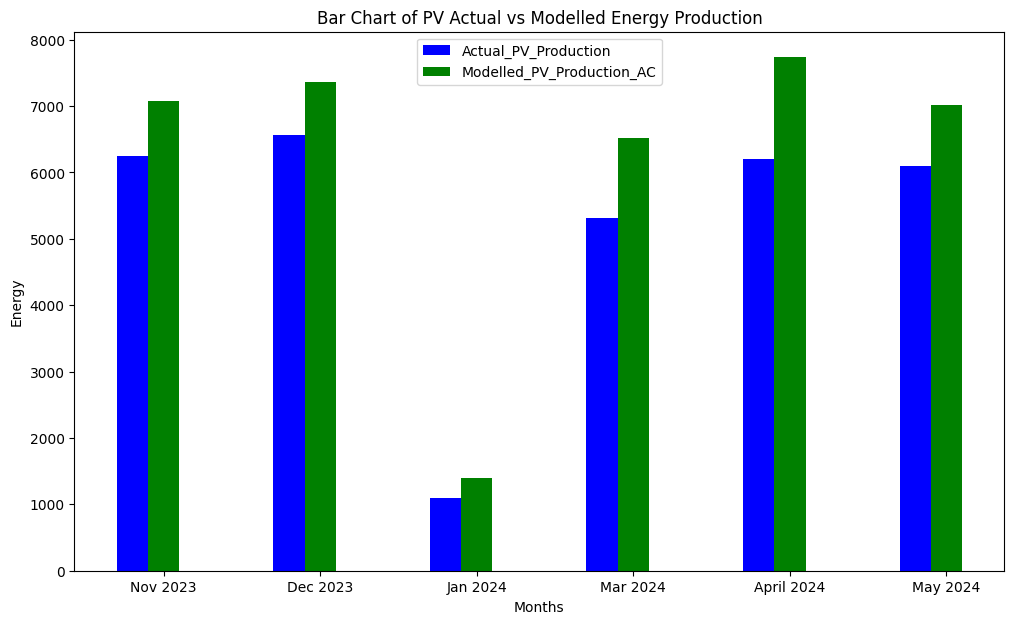

In [194]:
x = np.arange(6)
Months = ['Nov 2023', 'Dec 2023', 'Jan 2024', 'Mar 2024', 'April 2024', 'May 2024']
bar_width = 0.20
plt.figure(figsize=(12, 7))

plt.bar(x - bar_width, monthly_actual_energy_output, width=bar_width, label='Actual_PV_Production', color='blue')
plt.bar(x, monthly_modelled_energy_output_AC, width=bar_width, label='Modelled_PV_Production_AC', color='green')
#plt.bar(x + bar_width, monthly_modelled_energy_output_DC, width=bar_width, label='Modelled_PV_Production_DC', color='red')

plt.xlabel('Months')
plt.ylabel('Energy')
plt.title('Bar Chart of PV Actual vs Modelled Energy Production')
plt.xticks(x, Months)


plt.legend()
plt.show()

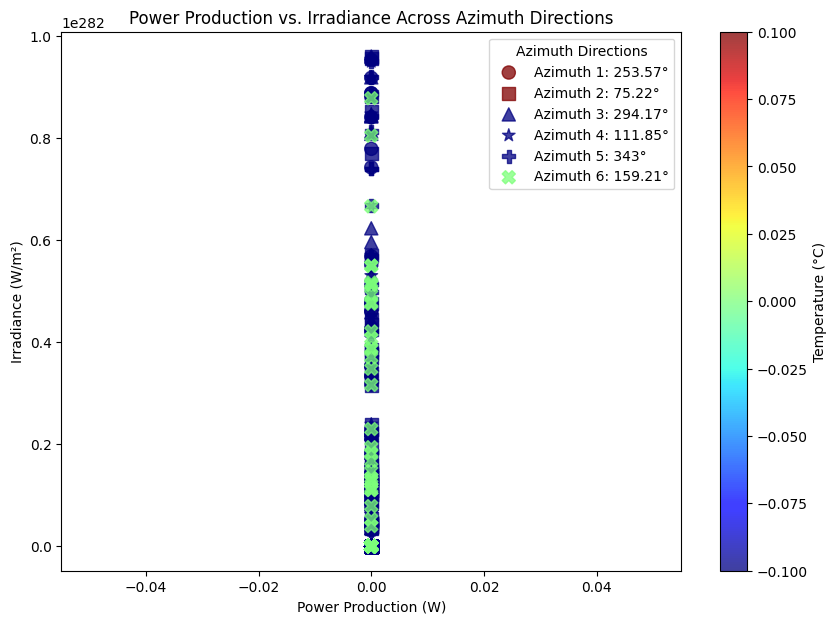

In [195]:
plt.figure(figsize=(10, 7))
markers = ['o', 's', '^', '*', 'P', 'X'] 
labels = [
    'Azimuth 1: 253.57°', 'Azimuth 2: 75.22°', 'Azimuth 3: 294.17°', 
    'Azimuth 4: 111.85°', 'Azimuth 5: 343°', 'Azimuth 6: 159.21°']

Num_Panels = np.array([25, 32, 60, 81, 12, 28])

for idx in range(6):
    scatter = plt.scatter(
        Power_Production_in_azimuth_directions[:, idx]/Num_Panels[idx],
        Irradiance_in_azimuth_directions[:, idx],
        c=Temperature_in_azimuth_directions[:, idx],
        cmap='jet',
        s=90,
        alpha=0.75,
        marker=markers[idx],
        label=labels[idx])

cbar = plt.colorbar(scatter)
cbar.set_label('Temperature (°C)')

plt.xlabel('Power Production (W)')
plt.ylabel('Irradiance (W/m²)')
plt.title('Power Production vs. Irradiance Across Azimuth Directions')
plt.legend(title="Azimuth Directions")
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))
markers = ['o', 's', '^', '*', 'P', 'X'] 
labels = [
    'Azimuth 1: 253.57° (25 modules)', 'Azimuth 2: 75.22° (32 modules)', 'Azimuth 3: 294.17° (60 modules)', 
    'Azimuth 4: 111.85° (81 modules)', 'Azimuth 5: 343° (12 modules)', 'Azimuth 6: 159.21° (28 modules)']


for idx in range(6):
    scatter = plt.scatter(
        Power_Production_in_azimuth_directions[:, idx],
        Irradiance_in_azimuth_directions[:, idx],
        c=Temperature_in_azimuth_directions[:, idx],
        cmap='jet',
        s=90,
        alpha=0.75,
        marker=markers[idx],
        label=labels[idx])

cbar = plt.colorbar(scatter)
cbar.set_label('Temperature (°C)')

plt.xlabel('Power Production (W)')
plt.ylabel('Irradiance (W/m²)')
plt.title('Power Production vs. Irradiance Across Azimuth Directions')
plt.legend(title="Azimuth Directions")
plt.show()

In [ ]:
print(f'Azimuth_2_max_POA_irradiance: {max(Irradiance_in_azimuth_directions[:,1])}')
print(f'Azimuth_4_max_POA_irradiance: {max(Irradiance_in_azimuth_directions[:,3])}')

In [2]:
One_year_data = pd.read_excel('C:/Users/Lenovo/OneDrive - Ashesi University/Desktop/Master Thesis/Energy_prod_data/Full_One_Year_Irradiance_Data.xlsx', engine='openpyxl')
One_year_data.head(3)

,Datetime,Hour,GHI,DNI,DHI,KT,Temp,WS10M
0,2023-05-01 01:00:00,01:00:00,0.0,0.0,0.0,-999.0,26.8,3.49
1,2023-05-01 02:00:00,02:00:00,0.0,0.0,0.0,-999.0,26.6,3.52
2,2023-05-01 03:00:00,03:00:00,0.0,0.0,0.0,-999.0,26.3,3.38


In [3]:
Day = np.array(One_year_data['Datetime'].dt.dayofyear)
Hour = np.array(One_year_data['Datetime'].dt.hour)
One_year_GHI_Irradiance = np.array(One_year_data['GHI'])
DNI__ = np.array(One_year_data['DNI'])
DHI__ = np.array(One_year_data['DHI'])
Ambient_Temperature = np.array(One_year_data['Temp'])
WindSpeed = np.array(One_year_data['WS10M'])
Location_lat = 5.7603

In [4]:
Simulation_Azimuth_angles = np.arange(90, 270, 2)
#Simulation_tilt_angles = np.arange(0, 90, 2)
Simulation_tilt_angles = 15
Simulation_STC_Power = 270

In [6]:
# Output_Array = [0]*len(Simulation_Azimuth_angles)
# Power_Array = np.empty((len(One_year_GHI_Irradiance), len(Simulation_Azimuth_angles)))
# Irradiance_Array = np.empty((len(One_year_GHI_Irradiance), len(Simulation_Azimuth_angles)))
# Cell_Temp_Array = np.empty((len(One_year_GHI_Irradiance), len(Simulation_Azimuth_angles)))

# MaxPower_in_optimal_tilt_azimuth = np.zeros((len(Simulation_tilt_angles), len(Simulation_Azimuth_angles)))


# for i, Simulation_tilt_angle in enumerate(Simulation_tilt_angles):
#     for index_1, (day, hour, irradiance, DNI, DHI, temperature, windspeed) in enumerate(zip(Day, Hour, One_year_GHI_Irradiance, DNI__, DHI__, Ambient_Temperature, WindSpeed)):
#         for index_2, Azimuth_angle in enumerate(Simulation_Azimuth_angles):
#             Output_Array[index_2] = PV_Power_Test(hour, day, Location_lat, Simulation_tilt_angle, Azimuth_angle, irradiance, DNI, DHI, Simulation_STC_Power, temperature, windspeed)
            
#             Power_Array[index_1, index_2] = Output_Array[index_2][0]
#             Irradiance_Array[index_1, index_2] = Output_Array[index_2][1]
#             Cell_Temp_Array[index_1, index_2] = Output_Array[index_2][2]
    
#         MaxPower_in_optimal_tilt_azimuth[i, :] = Power_Array.sum(axis = 0)

In [5]:
#Output_Array = np.array([0]*len(Simulation_Azimuth_angles))
Power_Array = np.empty((len(One_year_GHI_Irradiance), len(Simulation_Azimuth_angles)))
#Irradiance_Array = np.empty((len(One_year_GHI_Irradiance), len(Simulation_Azimuth_angles)))
#Cell_Temp_Array = np.empty((len(One_year_GHI_Irradiance), len(Simulation_Azimuth_angles)))

#MaxPower_in_optimal_tilt_azimuth = np.zeros((len(Simulation_tilt_angles), len(Simulation_Azimuth_angles)))


#for i, Simulation_tilt_angle in enumerate(Simulation_tilt_angles):
for index_1, (day, hour, irradiance, temperature, windspeed) in enumerate(zip(Day, Hour, One_year_GHI_Irradiance, Ambient_Temperature, WindSpeed)):
    for index_2, Azimuth_angle in enumerate(Simulation_Azimuth_angles):
        Output_Array = PV_Power_Test(day, hour, Location_lat, Simulation_tilt_angles, Azimuth_angle, irradiance, Simulation_STC_Power, temperature, windspeed)
        #print(Output_Array[index_2])
        Power_Array[index_1, index_2] = Output_Array[0]#[index_2]#[0]
        #Irradiance_Array[index_1, index_2] = Output_Array[index_2][1]
        #Cell_Temp_Array[index_1, index_2] = Output_Array[index_2][2]

    #MaxPower_in_optimal_tilt_azimuth[i, :] = Power_Array.sum(axis = 0)

In [10]:
len(Power_Array.sum(axis = 0)), len(Simulation_Azimuth_angles)

(90, 90)

In [ ]:
optimal_tilt_azimuth_index = unravel_index(MaxPower_in_optimal_tilt_azimuth.argmax(), MaxPower_in_optimal_tilt_azimuth.shape)
print(f'Optimal tilt angle is {Simulation_tilt_angles[optimal_tilt_azimuth_index[0]]}')
print('')
print(f'Optimal azimuth angle is {Simulation_Azimuth_angles[optimal_tilt_azimuth_index[1]]}')

In [ ]:

cmap = plt.colormaps["hsv"]
colors = cmap(np.linspace(0, 1, len(Simulation_Azimuth_angles)))

plt.figure(figsize=(15, 10))

labels = [f"Azimuth {(Simulation_Azimuth_angles[i])}" for i in range(len(Simulation_Azimuth_angles))]
# Loop through each index
for idx in range(len(Simulation_Azimuth_angles)):
    scatter = plt.scatter(
        Power_Array[:, idx],
        Irradiance_Array[:, idx],
        c=[colors[idx]],  
        s=90,
        alpha=0.75,
        label=labels[idx])

plt.xlabel('Power Production (W)')
plt.ylabel('Irradiance (W/m²)')
plt.title('Power Production vs. Irradiance Across Azimuth Directions')

# Legend with all 60 labels
plt.legend(title="Azimuth Directions", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
#plt.tight_layout()

# Show plot
plt.show()


In [ ]:
cmap = plt.colormaps["hsv"]
colors = cmap(np.linspace(0, 1, len(Simulation_Azimuth_angles)))

plt.figure(figsize=(15, 10))

labels = [f"Azimuth {(Simulation_Azimuth_angles[i])}" for i in range(len(Simulation_Azimuth_angles))]
# Loop through each index
for idx in range(len(Simulation_Azimuth_angles)):
    scatter = plt.scatter(
        sum(Power_Array[:, idx]/1000),
        sum(Irradiance_Array[:, idx]/1000),
        c=[colors[idx]],  
        s=90,
        alpha=0.75,
        label=labels[idx])

plt.xlabel('Power Production (KW)')
plt.ylabel('Irradiance (KW/m²)')
plt.title('Total Power Production vs. Total Irradiance Across Azimuth Directions')

# Legend with all 60 labels
plt.legend(title="Azimuth Directions", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
#plt.tight_layout()

# Show plot
plt.show()

In [ ]:
Total_Power_Array = []
for idx in range(len(Simulation_Azimuth_angles)):
    Total_Power_Array.append(np.sum(Power_Array[:,idx]))

for index, value in enumerate(Total_Power_Array):
    if value == np.max(Total_Power_Array):
        print(f'Max Total Energy Value: {round(value, 2)/1000} KWh ')
        print(f'Angle Corresponding to Max Total Energy Value: {Simulation_Azimuth_angles[index]} degrees')

##### 